# Предобработка данных

In [1]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
training_set = pd.read_csv('titanic.csv')
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
training_set.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [5]:
training_set.describe(include=['O'])

/var/folders/nx/cvp4nbcx5075w7wjhzyfgyd40000gn/T/ipykernel_26346/2198228790.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  training_set.describe(include=['O'])


,Name,Sex,Ticket,Cabin,Embarked
count,891,891,891,204,889
unique,891,2,681,147,3
top,"Braund, Mr. Owen Harris",male,347082,G6,S
freq,1,577,7,4,644


In [6]:
def custom_hist(training_set, title, xlabel, ylabel='Количество', bins=None):
    figsize = (20,6)
    plt.figure(figsize=figsize)
    plt.grid(True)
    plt.title(title)
    plt.hist(training_set, training_set.max().astype(int) if bins is None else bins)
    plt.xlabel(xlabel)
    plt.ylabel(ylabel)
    plt.show()

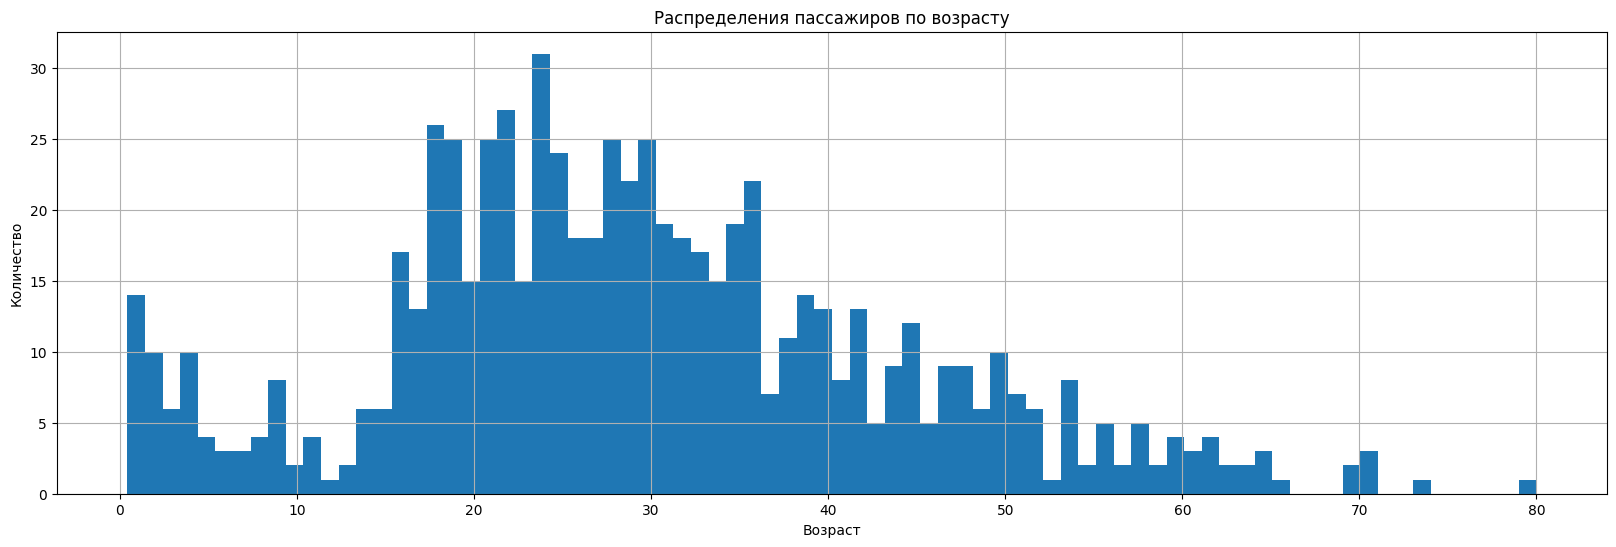

In [7]:
custom_hist(training_set["Age"], 'Распределения пассажиров по возрасту', 'Возраст')

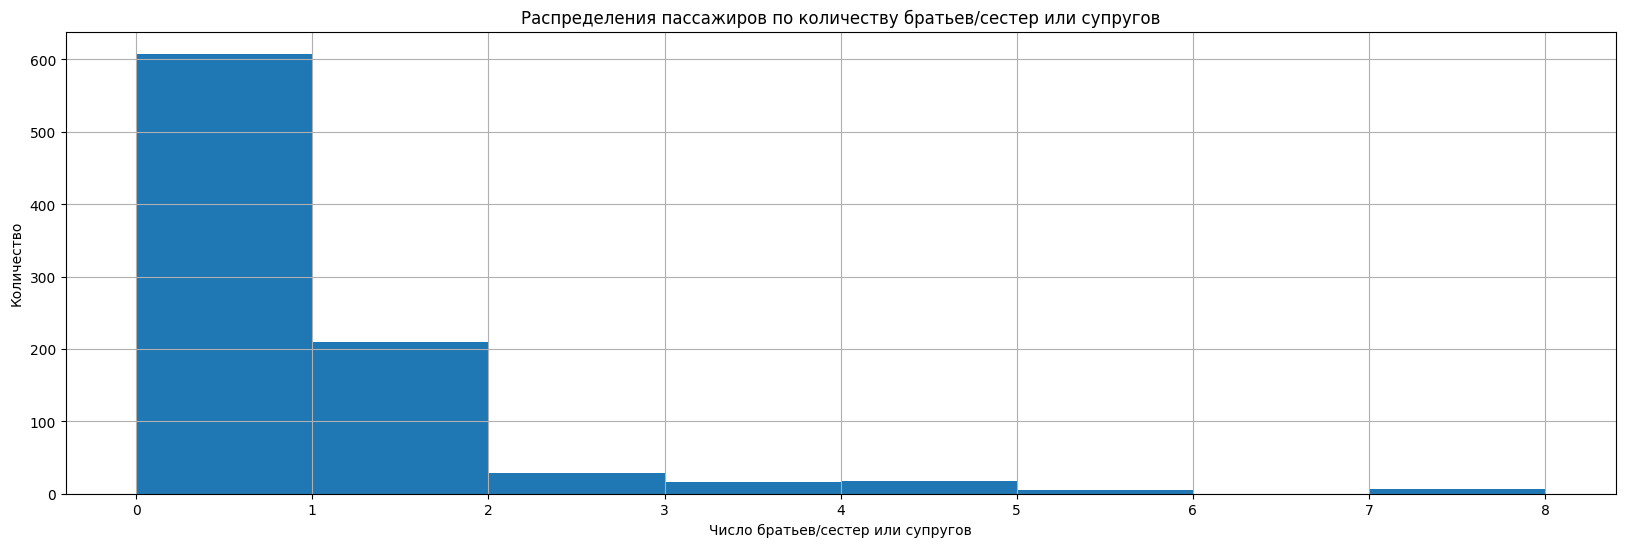

In [8]:
custom_hist(training_set["SibSp"], 'Распределения пассажиров по количеству братьев/сестер или супругов', 
            'Число братьев/сестер или супругов')

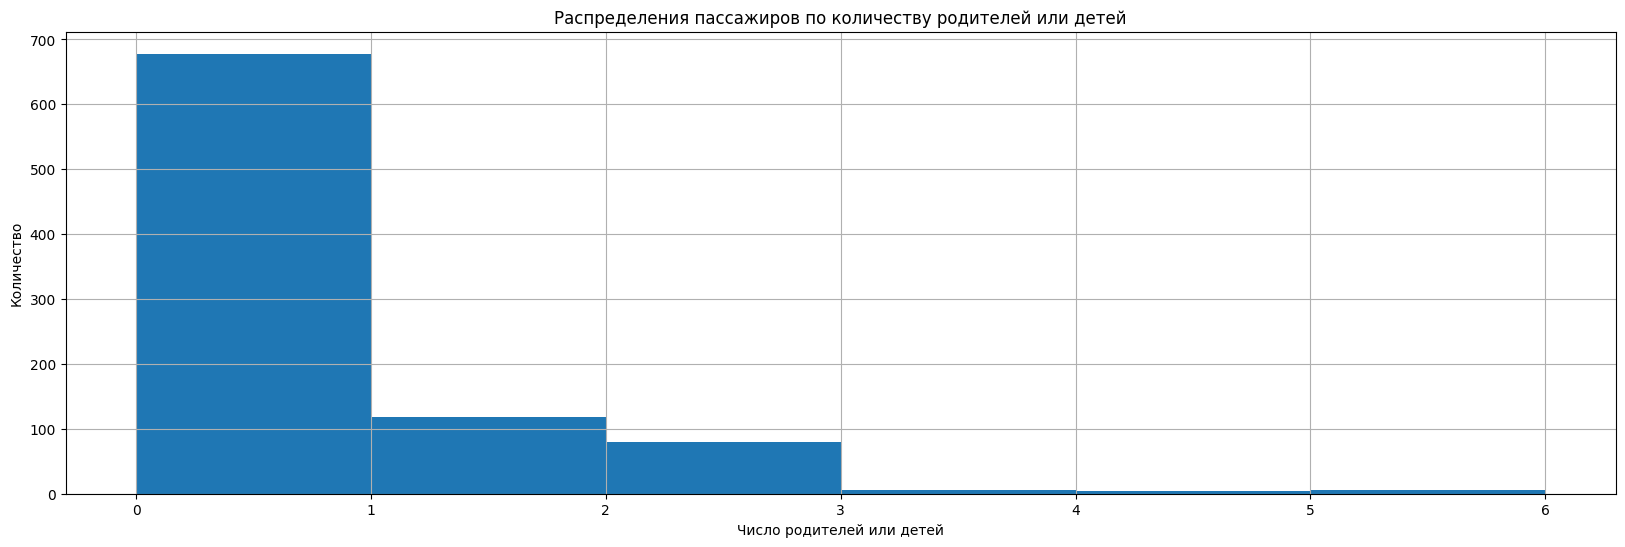

In [9]:
custom_hist(training_set["Parch"], 'Распределения пассажиров по количеству родителей или детей', 
            'Число родителей или детей')

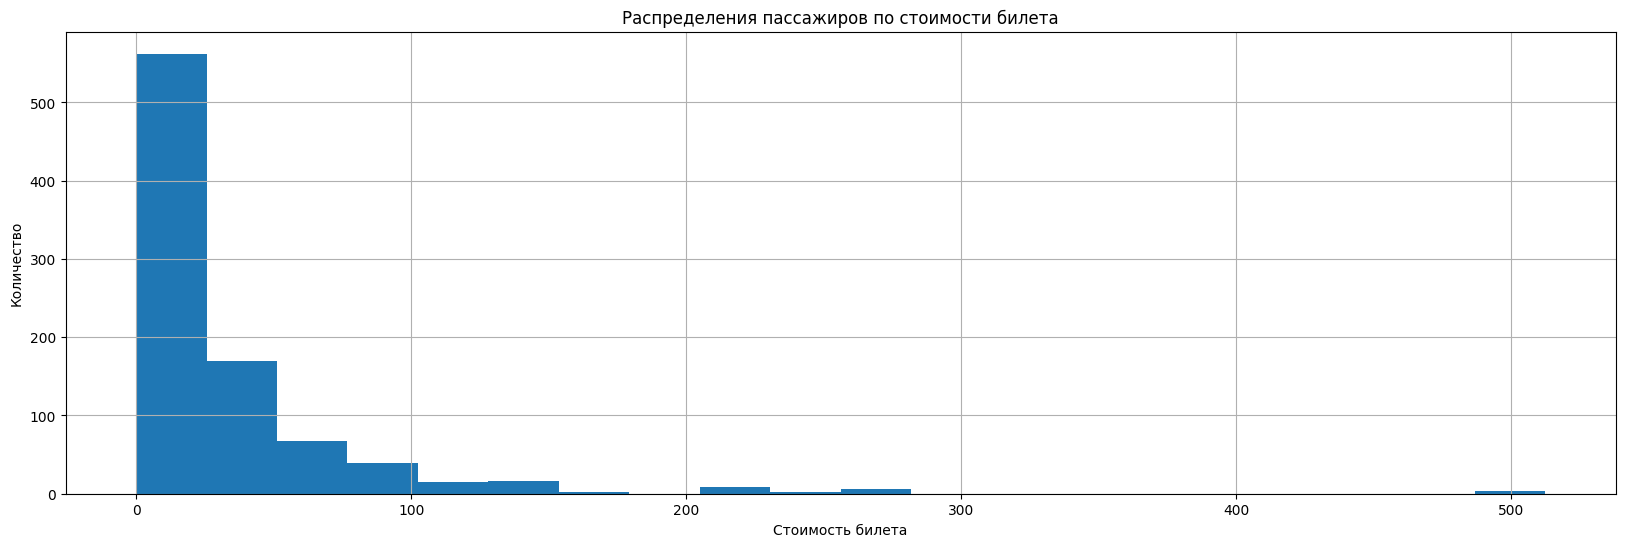

In [10]:
custom_hist(training_set["Fare"], 'Распределения пассажиров по стоимости билета', 
            'Стоимость билета', bins=20)

<Axes: ylabel='Frequency'>

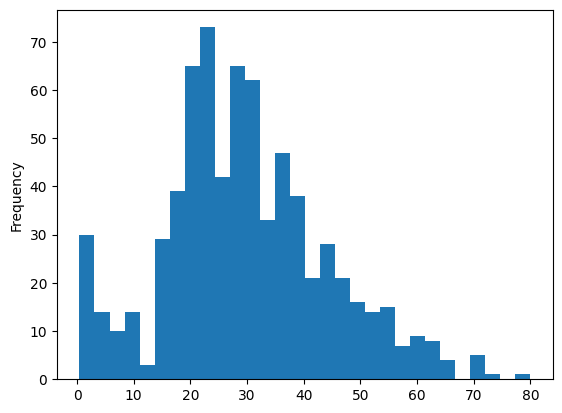

In [11]:
training_set['Age'].plot.hist(bins=30)

<Axes: xlabel='SibSp', ylabel='count'>

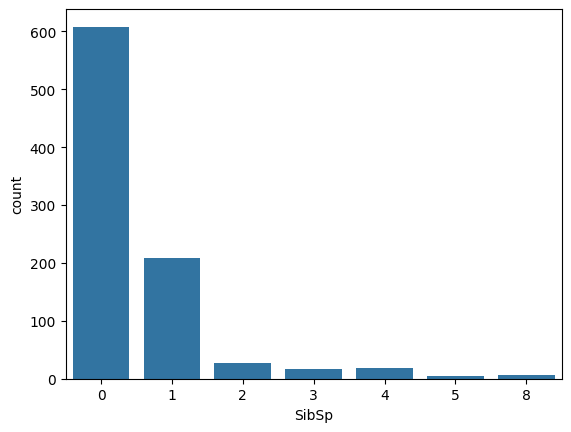

In [12]:
sns.countplot(x='SibSp', data=training_set)

In [13]:
training_set['Fare']

0       7.2500
1      71.2833
2       7.9250
3      53.1000
4       8.0500
        ...   
886    13.0000
887    30.0000
888    23.4500
889    30.0000
890     7.7500
Name: Fare, Length: 891, dtype: float64

<Axes: >

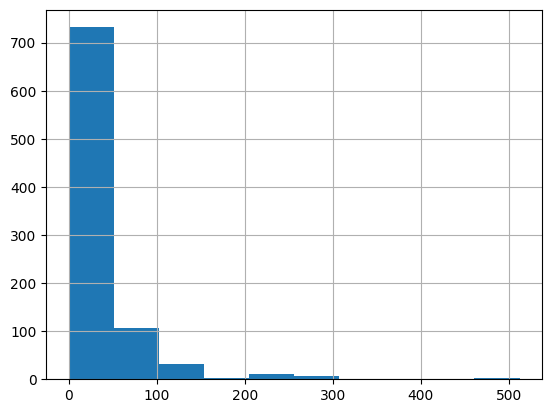

In [14]:
training_set['Fare'].hist()

<Axes: >

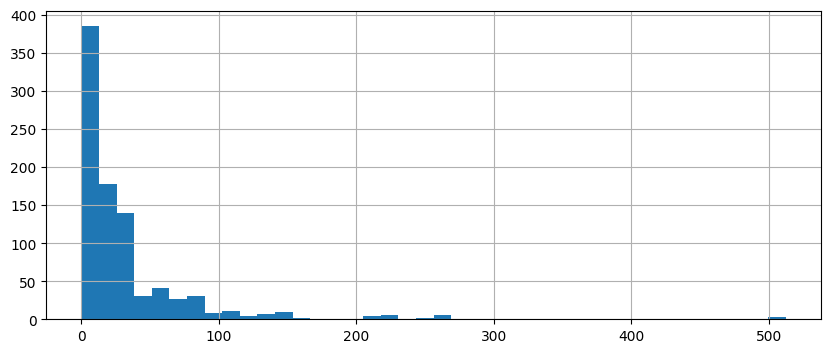

In [15]:
training_set['Fare'].hist(bins=40, figsize=(10,4))

<Axes: xlabel='Survived', ylabel='count'>

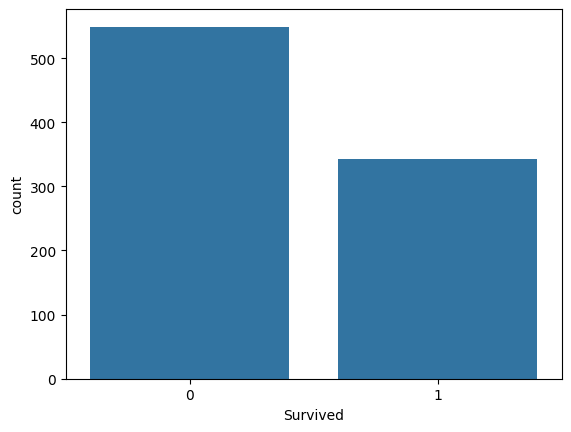

In [16]:
sns.countplot(x='Survived', data=training_set)

<Axes: xlabel='Survived', ylabel='count'>

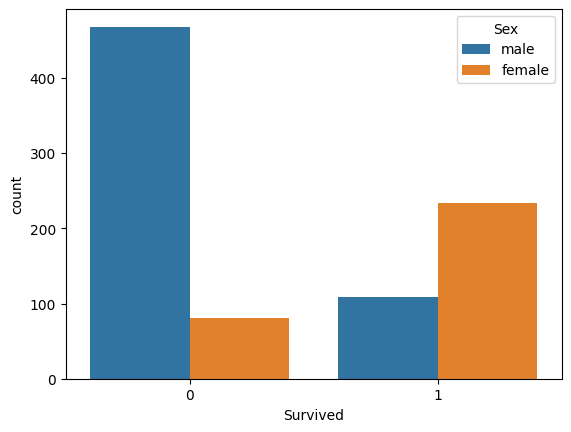

In [17]:
sns.countplot(x='Survived', data=training_set, hue='Sex')

<Axes: xlabel='Survived', ylabel='count'>

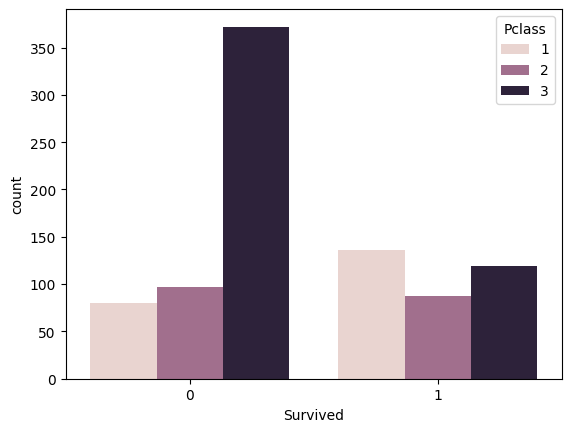

In [18]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Survived', ylabel='count'>

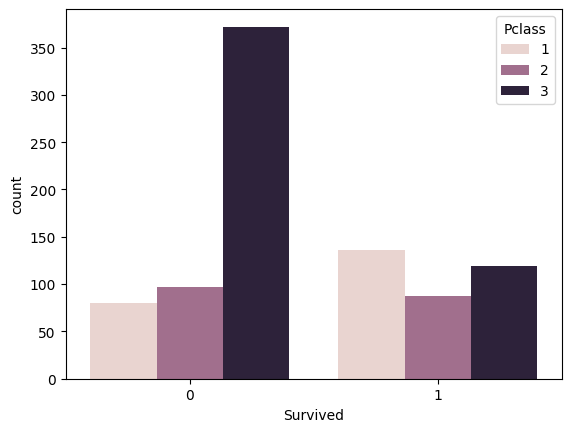

In [19]:
sns.countplot(x='Survived', data=training_set, hue='Pclass')

<Axes: xlabel='Pclass', ylabel='Age'>

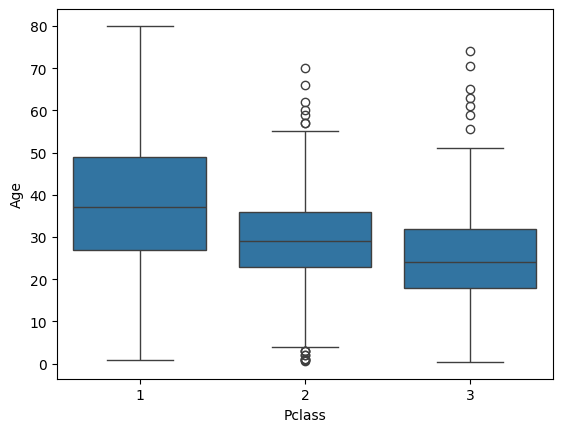

In [20]:
sns.boxplot(x='Pclass', y='Age', data=training_set)

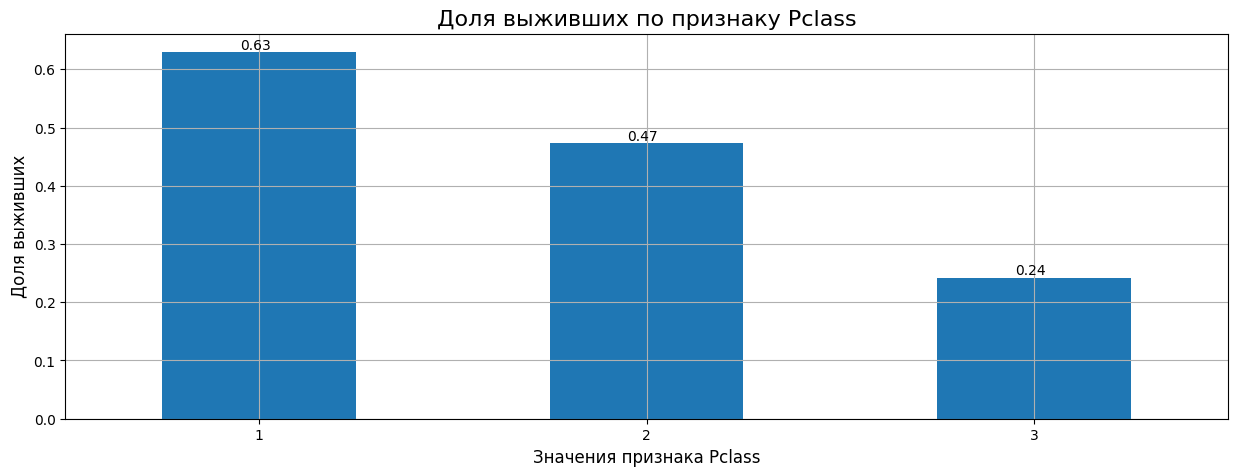

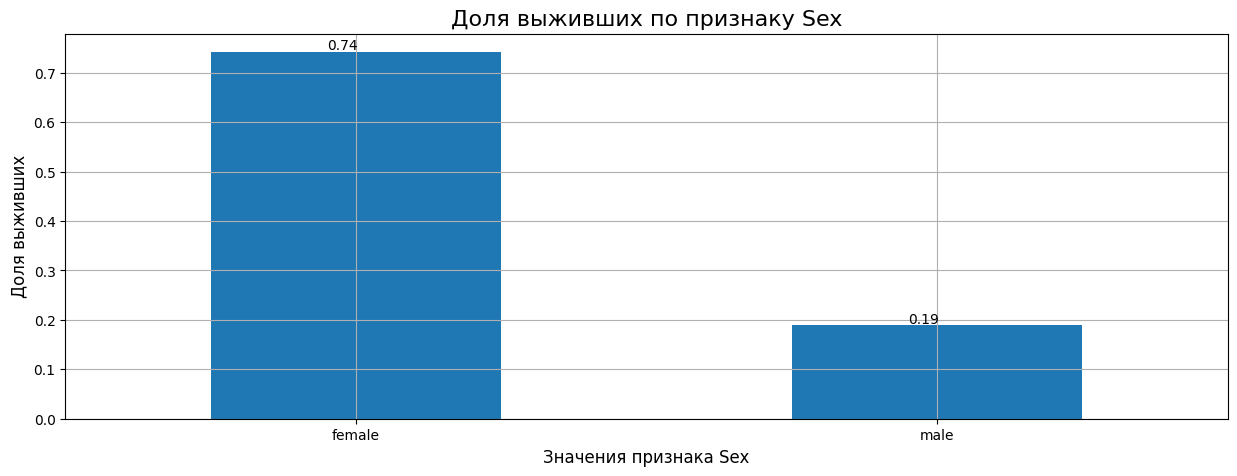

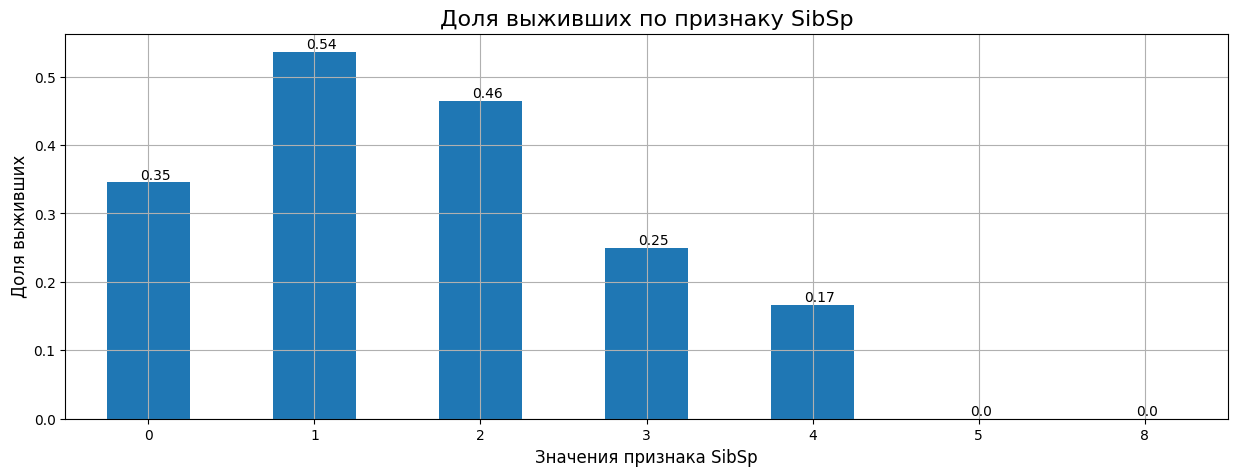

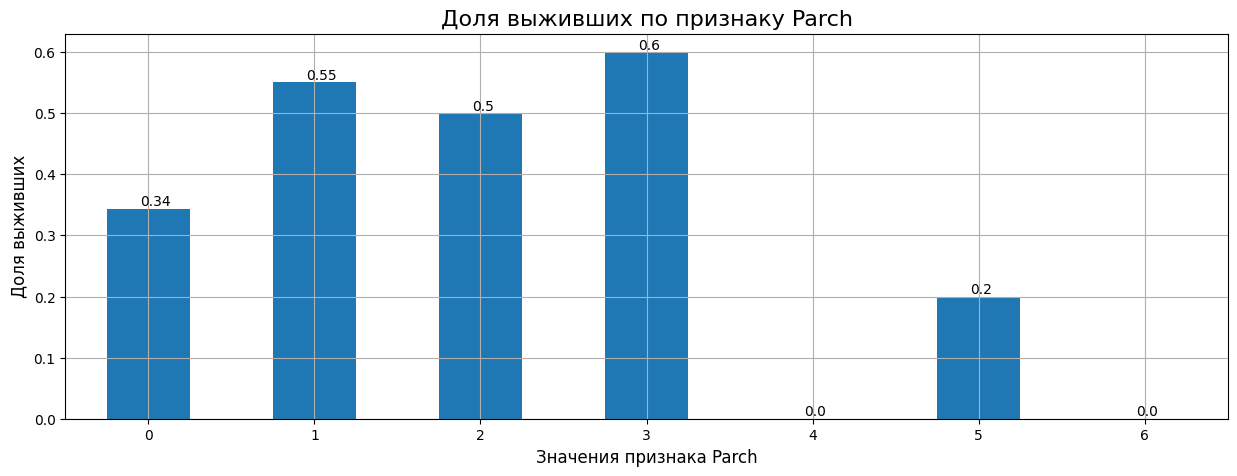

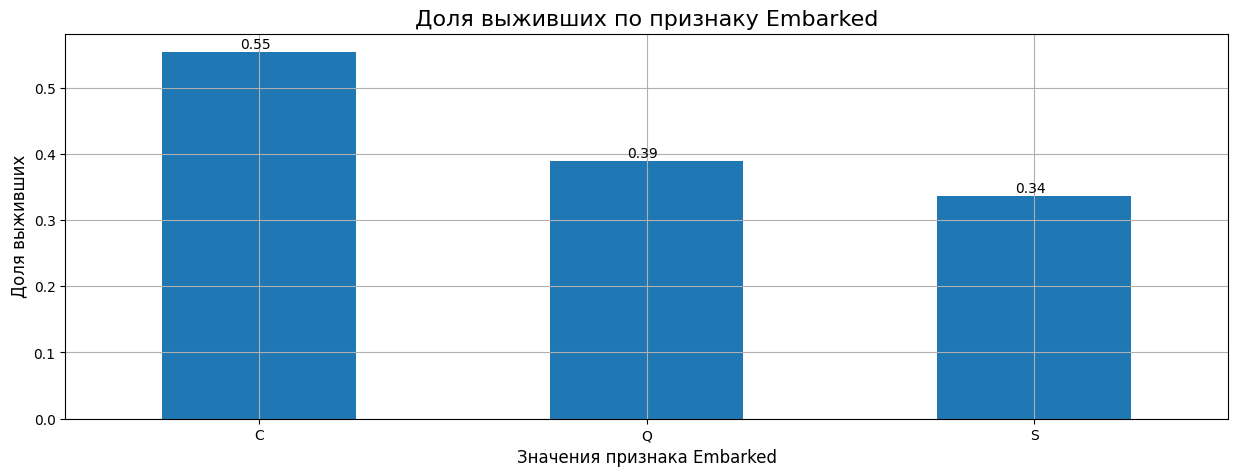

In [21]:
columns_to_look = ['Pclass', 'Sex', 'SibSp', 'Parch', 'Embarked']

for column in columns_to_look:
    pivot = training_set.pivot_table(index=column, values='Survived', aggfunc='mean')
    
    fig, ax = plt.subplots(figsize=(15,5))
    ax.set_title(f'Доля выживших по признаку {column}', fontdict={'size': 16})
    ax.set_ylabel('Доля выживших', fontdict={'size': 12})
    ax.set_xlabel(column, fontdict={'size': 12})
    
    for cnt in range(pivot.shape[0]):
        value = pivot.iloc[cnt].values[0]
        ax.text(cnt - .05, value + .005, round(value, 2))
        
    pivot.plot(kind='bar', rot=0, grid=True, legend=False, ax=ax) 
    ax.set_xlabel(f'Значения признака {column}', fontdict={'size': 12})
    plt.show()

In [22]:
training_set.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 83.7 KB


In [23]:
training_set.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [24]:
training_set.isnull()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,False,False,False,False,False,False,False,False,False,False,True,False
1,False,False,False,False,False,False,False,False,False,False,False,False
2,False,False,False,False,False,False,False,False,False,False,True,False
3,False,False,False,False,False,False,False,False,False,False,False,False
4,False,False,False,False,False,False,False,False,False,False,True,False
...,...,...,...,...,...,...,...,...,...,...,...,...
886,False,False,False,False,False,False,False,False,False,False,True,False
887,False,False,False,False,False,False,False,False,False,False,False,False
888,False,False,False,False,False,True,False,False,False,False,True,False
889,False,False,False,False,False,False,False,False,False,False,False,False


<Axes: >

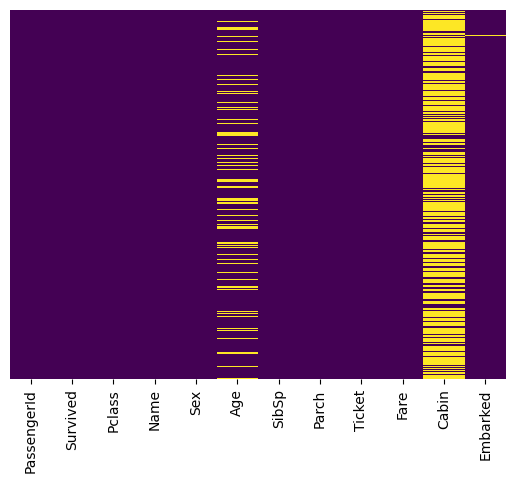

In [25]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [26]:
training_set.drop('Cabin', axis=1, inplace=True)
training_set.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,S


<Axes: >

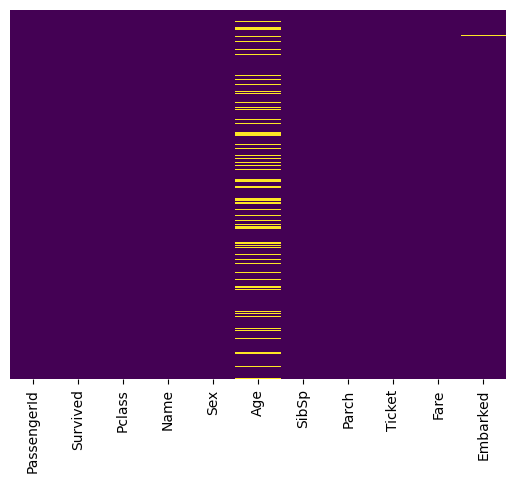

In [27]:
sns.heatmap(training_set.isnull(), yticklabels=False, cbar=False, cmap='viridis')

In [28]:
training_set.dropna(inplace=True)
training_set.info()

<class 'pandas.DataFrame'>
Index: 712 entries, 0 to 890
Data columns (total 11 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  712 non-null    int64  
 1   Survived     712 non-null    int64  
 2   Pclass       712 non-null    int64  
 3   Name         712 non-null    str    
 4   Sex          712 non-null    str    
 5   Age          712 non-null    float64
 6   SibSp        712 non-null    int64  
 7   Parch        712 non-null    int64  
 8   Ticket       712 non-null    str    
 9   Fare         712 non-null    float64
 10  Embarked     712 non-null    str    
dtypes: float64(2), int64(5), str(4)
memory usage: 66.8 KB


In [29]:
from sklearn.preprocessing import OneHotEncoder, LabelEncoder

In [30]:
le = LabelEncoder()
cat_enc_le = le.fit_transform(training_set['Sex'])
print(training_set['Sex'].unique())
print(np.unique(cat_enc_le))
print(le.inverse_transform([0,1]))

<StringArray>
['male', 'female']
Length: 2, dtype: str
[0 1]
['female' 'male']


In [31]:
ohe = OneHotEncoder()
cat_enc_ohe = ohe.fit_transform(training_set[['Embarked']])
print("Исходная форма:", training_set.shape)
print("Форма после OHE:", cat_enc_ohe.shape)

Исходная форма: (712, 11)
Форма после OHE: (712, 3)


In [32]:
sex = pd.get_dummies(training_set['Sex'], drop_first=True)
embark = pd.get_dummies(training_set['Embarked'], drop_first=True)

print(sex.head())
print(embark.head())

    male
0   True
1  False
2  False
3  False
4   True
       Q      S
0  False   True
1  False  False
2  False   True
3  False   True
4  False   True


In [33]:
training_set = pd.concat([training_set, sex, embark], axis=1)
training_set.drop(['Sex', 'Embarked', 'Name', 'Ticket', 'PassengerId'], axis=1, inplace=True)
training_set.head()

,Survived,Pclass,Age,SibSp,Parch,Fare,male,Q,S
0,0,3,22.0,1,0,7.2500,True,False,True
1,1,1,38.0,1,0,71.2833,False,False,False
2,1,3,26.0,0,0,7.9250,False,False,True
3,1,1,35.0,1,0,53.1000,False,False,True
4,0,3,35.0,0,0,8.0500,True,False,True


# Задания для самостоятельного выполнения

# Задание 1

In [34]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, classification_report

X = training_set.drop('Survived', axis=1)
y = training_set['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

model = LogisticRegression(max_iter=1000)
model.fit(X_train, y_train)
y_pred = model.predict(X_test)

print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

Accuracy: 0.7972
              precision    recall  f1-score   support

           0       0.77      0.91      0.83        80
           1       0.85      0.65      0.74        63

    accuracy                           0.80       143
   macro avg       0.81      0.78      0.79       143
weighted avg       0.81      0.80      0.79       143



# Задание 2

In [35]:
# Доля выживших
survived_rate = training_set['Survived'].mean()
print(f"Доля выживших пассажиров: {survived_rate:.2%}")

# Доля мужчин и женщин среди выживших (используем исходный пол, но в преобразованном датасете у нас есть столбец 'male')
# male = 1 – мужчина, 0 – женщина
survived_male = training_set[training_set['Survived'] == 1]['male'].mean()
print(f"Доля мужчин среди выживших: {survived_male:.2%}")
print(f"Доля женщин среди выживших: {1 - survived_male:.2%}")

Доля выживших пассажиров: 40.45%
Доля мужчин среди выживших: 32.29%
Доля женщин среди выживших: 67.71%


# Задание 3

In [36]:
# Количество пассажиров в каждом классе
class_counts = training_set['Pclass'].value_counts().sort_index()
print("Количество пассажиров по классам:")
print(class_counts)

# Самый многолюдный класс
most_popular_class = class_counts.idxmax()
print(f"\nСамый многолюдный класс: {most_popular_class}")

# Соотношение мужчин и женщин в этом классе
class_data = training_set[training_set['Pclass'] == most_popular_class]
male_count = class_data['male'].sum()
female_count = len(class_data) - male_count
print(f"В классе {most_popular_class}: мужчин = {male_count}, женщин = {female_count}")

Количество пассажиров по классам:
Pclass
1    184
2    173
3    355
Name: count, dtype: int64

Самый многолюдный класс: 3
В классе 3: мужчин = 253, женщин = 102


# Задание 4

In [37]:
# В нашем датасете уже удалены Name, Ticket, PassengerId, Cabin.
# Проверим корреляцию с целевой переменной
correlations = training_set.corr()['Survived'].abs().sort_values(ascending=False)
print("Корреляция признаков с выживаемостью:")
print(correlations)

# Признаки с низкой корреляцией (<0.05) возможно стоит удалить
low_corr = correlations[correlations < 0.05].index.tolist()
print(f"\nПризнаки с корреляцией ниже 0.05: {low_corr}")

Корреляция признаков с выживаемостью:
Survived    1.000000
male        0.536762
Pclass      0.356462
Fare        0.266100
S           0.159015
Parch       0.095265
Age         0.082446
Q           0.048966
SibSp       0.015523
Name: Survived, dtype: float64

Признаки с корреляцией ниже 0.05: ['Q', 'SibSp']


# Задание 5

Корреляция Пирсона между Fare и Age: 0.0931


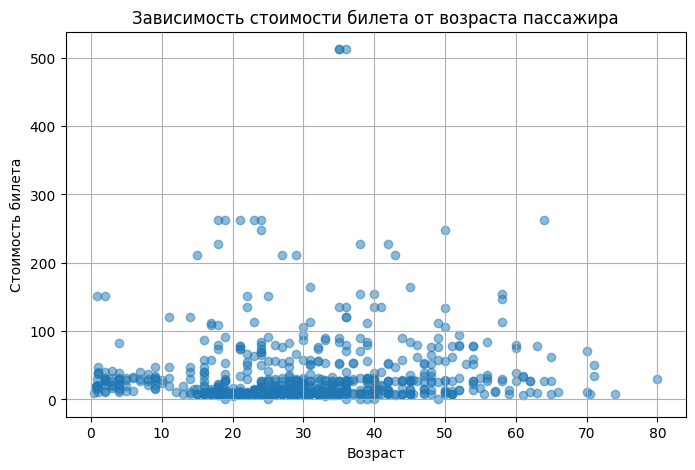

In [38]:
corr_fare_age = training_set['Fare'].corr(training_set['Age'])
print(f"Корреляция Пирсона между Fare и Age: {corr_fare_age:.4f}")

# Диаграмма рассеяния
plt.figure(figsize=(8,5))
plt.scatter(training_set['Age'], training_set['Fare'], alpha=0.5)
plt.xlabel('Возраст')
plt.ylabel('Стоимость билета')
plt.title('Зависимость стоимости билета от возраста пассажира')
plt.grid(True)
plt.show()

# Задание 6

<Figure size 1000x500 with 0 Axes>

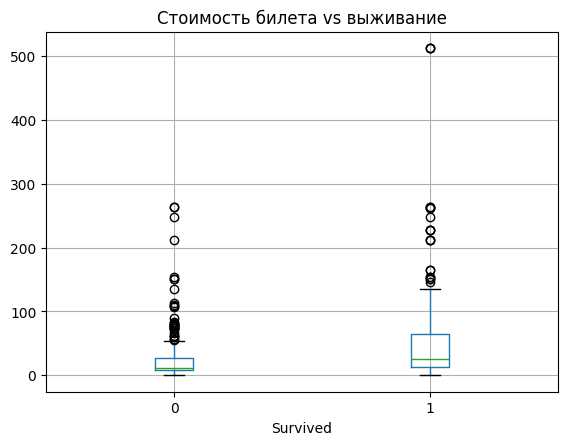

Средняя стоимость билета выживших: 51.647671875
Средняя стоимость билета погибших: 22.96545636792453

Доля выживших по классам:
Pclass
1    0.652174
2    0.479769
3    0.239437
Name: Survived, dtype: float64


In [39]:
# Сравнение стоимости билетов у выживших и погибших
plt.figure(figsize=(10,5))
training_set.boxplot(column='Fare', by='Survived')
plt.title('Стоимость билета vs выживание')
plt.suptitle('')
plt.show()

print("Средняя стоимость билета выживших:", training_set[training_set['Survived']==1]['Fare'].mean())
print("Средняя стоимость билета погибших:", training_set[training_set['Survived']==0]['Fare'].mean())

# Зависимость выживаемости от класса
survival_by_class = training_set.groupby('Pclass')['Survived'].mean()
print("\nДоля выживших по классам:")
print(survival_by_class)

# Задание 7

In [40]:
# Порты: у нас есть столбцы Q и S (one-hot), исходный порт можно восстановить
# Создадим колонку Embarked_original для удобства
def get_embarked(row):
    if row['Q'] == 1:
        return 'Q'
    elif row['S'] == 1:
        return 'S'
    else:
        return 'C'  # если оба 0, значит C
training_set['Embarked_original'] = training_set.apply(get_embarked, axis=1)

fare_stats = training_set.groupby('Embarked_original')['Fare'].agg(['min', 'mean', 'max'])
print("Статистика стоимости билета по портам отправления:")
print(fare_stats)

# Только для Саутгемптона (S)
southampton_fares = training_set[training_set['Embarked_original'] == 'S']['Fare']
print("\nСтатистика для Саутгемптона:")
print(f"Минимум: {southampton_fares.min():.2f}, Среднее: {southampton_fares.mean():.2f}, Максимум: {southampton_fares.max():.2f}")

Статистика стоимости билета по портам отправления:
                      min       mean       max
Embarked_original                             
C                  4.0125  68.296767  512.3292
Q                  6.7500  18.265775   90.0000
S                  0.0000  27.476284  263.0000

Статистика для Саутгемптона:
Минимум: 0.00, Среднее: 27.48, Максимум: 263.00


# Задание 8

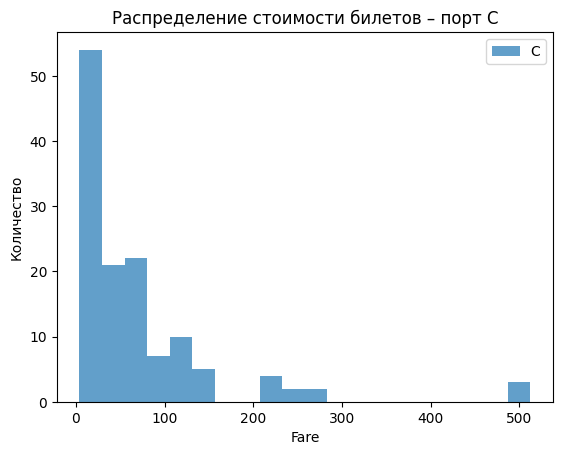

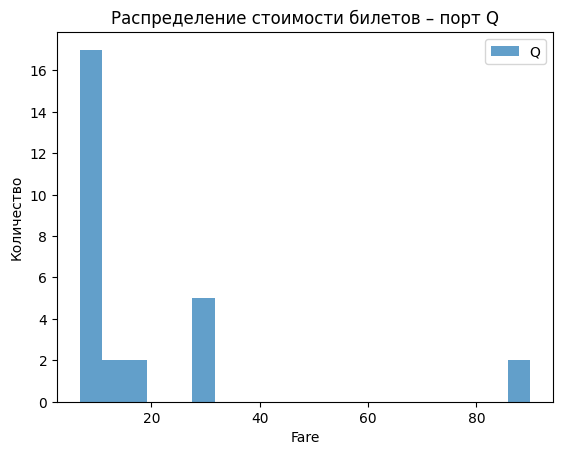

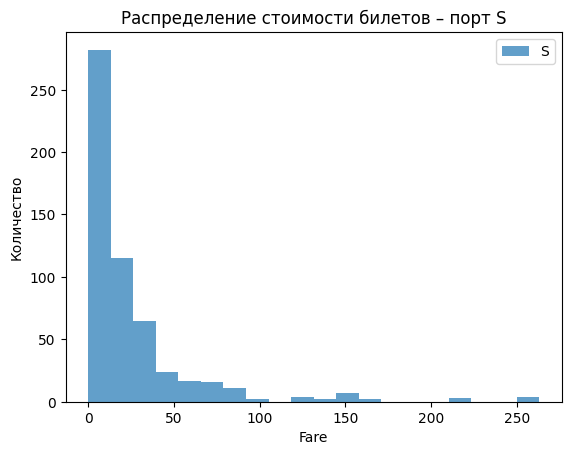

In [41]:
for port in ['C', 'Q', 'S']:
    plt.figure()
    data = training_set[training_set['Embarked_original'] == port]['Fare']
    plt.hist(data, bins=20, alpha=0.7, label=port)
    plt.title(f'Распределение стоимости билетов – порт {port}')
    plt.xlabel('Fare')
    plt.ylabel('Количество')
    plt.legend()
    plt.show()

# Задание 9

In [42]:
# Известные исторические данные: всего пассажиров ~2224, выжило ~710 (источники могут слегка различаться)
total_actual = 2224
survived_actual = 710

sample_total = len(training_set)
sample_survived = training_set['Survived'].sum()

print(f"Размер выборки: {sample_total} (из {total_actual} реальных) – доля {sample_total/total_actual:.2%}")
print(f"Выживших в выборке: {sample_survived} (из {survived_actual} реальных) – доля {sample_survived/survived_actual:.2%}")

Размер выборки: 712 (из 2224 реальных) – доля 32.01%
Выживших в выборке: 288 (из 710 реальных) – доля 40.56%


# Задание 10

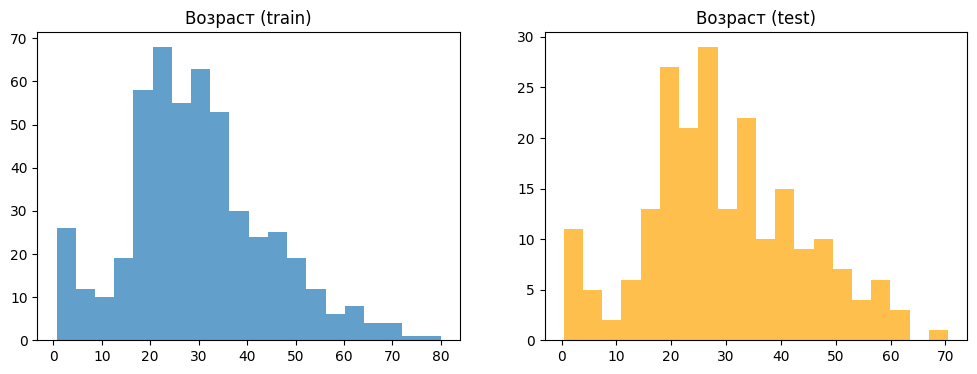

Доля выживших в train: 0.39357429718875503
Доля выживших в test: 0.42990654205607476


In [43]:
from sklearn.model_selection import train_test_split

X = training_set.drop('Survived', axis=1)
y = training_set['Survived']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

# Сравним распределение возраста в train и test
fig, axes = plt.subplots(1,2, figsize=(12,4))
axes[0].hist(X_train['Age'], bins=20, alpha=0.7, label='Train')
axes[0].set_title('Возраст (train)')
axes[1].hist(X_test['Age'], bins=20, alpha=0.7, label='Test', color='orange')
axes[1].set_title('Возраст (test)')
plt.show()

# Распределение целевой переменной
print("Доля выживших в train:", y_train.mean())
print("Доля выживших в test:", y_test.mean())

# Задание 11

In [44]:
# Объединяем X и y для удобства
train_df = X_train.copy()
train_df['Survived'] = y_train

# Определим мажоритарный и миноритарный классы
majority_class = 0 if (y_train == 0).sum() > (y_train == 1).sum() else 1
minority_class = 1 - majority_class

majority = train_df[train_df['Survived'] == majority_class]
minority = train_df[train_df['Survived'] == minority_class]

# Андерсемплинг (удаляем лишние объекты мажоритарного класса)
under_majority = majority.sample(n=len(minority), random_state=42)
under_df = pd.concat([under_majority, minority])

# Оверсемплинг (добавляем дубликаты миноритарного класса)
oversampled_minority = minority.sample(n=len(majority) - len(minority), replace=True, random_state=42)
over_df = pd.concat([majority, minority, oversampled_minority])

print("Размеры после андерсемплинга:", under_df.shape)
print("Размеры после оверсемплинга:", over_df.shape)

Размеры после андерсемплинга: (392, 10)
Размеры после оверсемплинга: (604, 10)


In [50]:
# Выбираем только числовые колонки (int, float)
numeric_cols = training_set.select_dtypes(include=[np.number]).columns.tolist()
print("Числовые колонки:", numeric_cols)

# Отделяем X и y
X_num = training_set[numeric_cols].drop('Survived', axis=1)
y_num = training_set['Survived']

# Разделяем на train/test (30% тест)
from sklearn.model_selection import train_test_split
X_train_num, X_test_num, y_train_num, y_test_num = train_test_split(X_num, y_num, test_size=0.3, random_state=42)

Числовые колонки: ['Survived', 'Pclass', 'Age', 'SibSp', 'Parch', 'Fare']


# Задание 12

In [51]:
# Объединим для удобства
train_df = X_train_num.copy()
train_df['Survived'] = y_train_num

# Определим мажоритарный и миноритарный классы
if (y_train_num == 0).sum() > (y_train_num == 1).sum():
    majority_class = 0
    minority_class = 1
else:
    majority_class = 1
    minority_class = 0

majority = train_df[train_df['Survived'] == majority_class]
minority = train_df[train_df['Survived'] == minority_class]

# Андерсемплинг (урезаем мажоритарный)
under_majority = majority.sample(n=len(minority), random_state=42)
under_df = pd.concat([under_majority, minority])

# Оверсемплинг (дублируем миноритарный)
oversampled_minority = minority.sample(n=len(majority) - len(minority), replace=True, random_state=42)
over_df = pd.concat([majority, minority, oversampled_minority])

print("Размер after under:", under_df.shape)
print("Размер after over: ", over_df.shape)

Размер after under: (392, 6)
Размер after over:  (604, 6)


# Задание 13

In [52]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report

# Исходная модель
model_orig = LogisticRegression(max_iter=1000)
model_orig.fit(X_train_num, y_train_num)
y_pred_orig = model_orig.predict(X_test_num)

print("=== ИСХОДНАЯ МОДЕЛЬ (несбалансированная) ===")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_orig):.4f}")
print(classification_report(y_test_num, y_pred_orig))

# Модель после андерсемплинга
X_under = under_df.drop('Survived', axis=1)
y_under = under_df['Survived']
model_under = LogisticRegression(max_iter=1000)
model_under.fit(X_under, y_under)
y_pred_under = model_under.predict(X_test_num)

print("\n=== МОДЕЛЬ ПОСЛЕ АНДЕРСЕМПЛИНГА ===")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_under):.4f}")
print(classification_report(y_test_num, y_pred_under))

# Модель после оверсемплинга
X_over = over_df.drop('Survived', axis=1)
y_over = over_df['Survived']
model_over = LogisticRegression(max_iter=1000)
model_over.fit(X_over, y_over)
y_pred_over = model_over.predict(X_test_num)

print("\n=== МОДЕЛЬ ПОСЛЕ ОВЕРСЕМПЛИНГА ===")
print(f"Accuracy: {accuracy_score(y_test_num, y_pred_over):.4f}")
print(classification_report(y_test_num, y_pred_over))

=== ИСХОДНАЯ МОДЕЛЬ (несбалансированная) ===
Accuracy: 0.6589
              precision    recall  f1-score   support

           0       0.67      0.80      0.73       122
           1       0.64      0.48      0.55        92

    accuracy                           0.66       214
   macro avg       0.65      0.64      0.64       214
weighted avg       0.66      0.66      0.65       214


=== МОДЕЛЬ ПОСЛЕ АНДЕРСЕМПЛИНГА ===
Accuracy: 0.6729
              precision    recall  f1-score   support

           0       0.72      0.70      0.71       122
           1       0.61      0.64      0.63        92

    accuracy                           0.67       214
   macro avg       0.67      0.67      0.67       214
weighted avg       0.67      0.67      0.67       214


=== МОДЕЛЬ ПОСЛЕ ОВЕРСЕМПЛИНГА ===
Accuracy: 0.6542
              precision    recall  f1-score   support

           0       0.70      0.69      0.69       122
           1       0.60      0.61      0.60        92

    accuracy 

# Задание 14

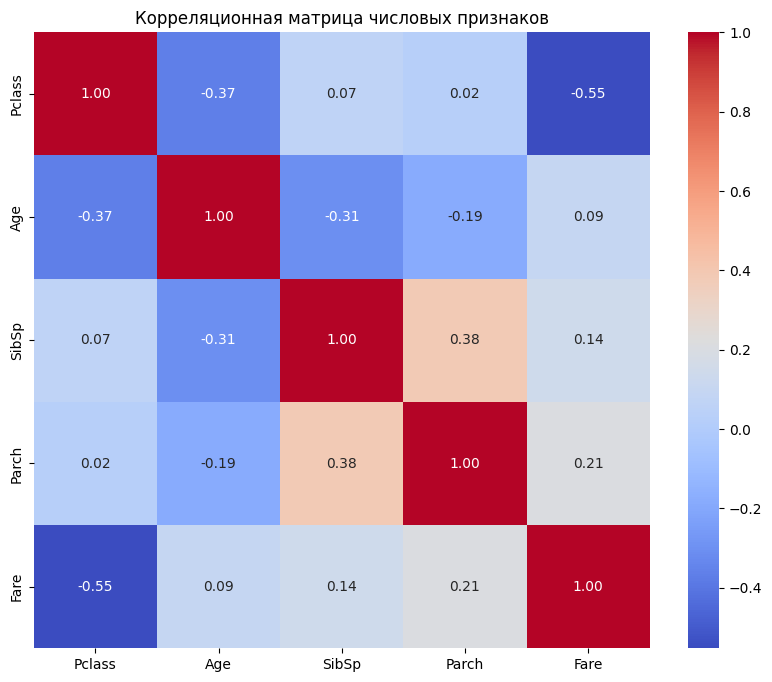

In [54]:
corr_matrix = X_num.corr()   # корреляция между признаками (без Survived)
plt.figure(figsize=(10,8))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap='coolwarm', square=True)
plt.title('Корреляционная матрица числовых признаков')
plt.show()

# Найдём пары с высокой корреляцией (>0.8)
high_corr = (corr_matrix.abs() > 0.8) & (corr_matrix != 1.0)
pairs = [(i, j) for i in high_corr.columns for j in high_corr.index if high_corr.loc[i, j] and i < j]


# Задание 15

In [55]:
# Создаём категории (без строк – только для перевода в числа)
def age_cat(age):
    if age < 18:
        return 0   # ребёнок
    elif age < 60:
        return 1   # взрослый
    else:
        return 2   # старик

training_set['AgeGroup'] = training_set['Age'].apply(age_cat)

# Используем one‑hot encoding (числовые столбцы)
age_dummies = pd.get_dummies(training_set['AgeGroup'], prefix='Age', drop_first=True)
training_set = pd.concat([training_set, age_dummies], axis=1)

# Теперь добавим эти новые признаки в числовую матрицу X
X_num_enhanced = training_set[numeric_cols + ['Age_1', 'Age_2']].drop('Survived', axis=1)
y_enhanced = training_set['Survived']

# Оценим влияние возрастных категорий
model_age = LogisticRegression(max_iter=1000)
model_age.fit(X_num_enhanced, y_enhanced)

# Посмотрим коэффициенты для возрастных dummy
print("\nКоэффициенты для возрастных категорий:")
coeffs = model_age.coef_[0]
if 'Age_1' in X_num_enhanced.columns:
    idx1 = X_num_enhanced.columns.get_loc('Age_1')
    idx2 = X_num_enhanced.columns.get_loc('Age_2')
    print(f"  'взрослый' (Age_1): {coeffs[idx1]:.4f}")
    print(f"  'старик'   (Age_2): {coeffs[idx2]:.4f}")


Коэффициенты для возрастных категорий:
  'взрослый' (Age_1): -0.6045
  'старик'   (Age_2): -0.9117
